# 03: Time-Varying Confounding and Propensity Weights

Notebook 01 turned KuaiRec into a sequential user-day panel. Notebook 02 defined the primary causal estimand:

> Among active KuaiRec user-days with sufficient prior history and 7-day follow-up, estimate the effect of a high-watch-exposure day on future 7-day interaction volume.

This notebook handles the next causal-design problem: **treatment assignment is not random**. A user is more likely to have a high-watch-exposure day when their recent history, preferences, activity level, and calendar context make that kind of day more likely. Those same pre-treatment factors can also predict future engagement. That is the classic time-varying confounding problem in recommender systems.

The goal of this notebook is to estimate the probability of treatment from pre-treatment information, diagnose overlap and positivity, and create stabilized inverse probability weights. These weights are the handoff to the next notebook, where we can fit a marginal structural model for the long-term treatment effect.


<!-- dataset-experiment-context -->
## Dataset and Sequential Design Context

This project uses KuaiRec interaction logs organized into a user-day panel. The raw data contain user-video interactions, watch behavior, user features, item metadata, and item daily popularity information.

This is a real observational sequential recommendation log, not a randomized exposure experiment. The treatment is a constructed high-watch-exposure day, the primary outcome is future seven-day engagement, and lagged user behavior is both a predictor of treatment and a predictor of future outcomes.

The project studies a sequential causal question: whether short-term exposure is associated with later engagement after adjusting for observed history. Marginal structural models, g-computation, doubly robust estimation, overlap diagnostics, and heterogeneity checks are used to decide whether the evidence is strong enough to motivate a future online test.

**Role of this notebook.** This notebook diagnoses time-varying confounding by modeling treatment assignment from lagged user behavior and checking propensity overlap.

<!-- mathematical-setup -->

## Mathematical Setup

In longitudinal data, prior behavior can affect both today’s treatment and future outcomes. The time-varying propensity score is

$$
e_{it}=\Pr(A_{it}=1\mid H_{it}),
$$

where \(H_{it}\) contains pre-treatment user history. Stabilized inverse-probability weights compare observed treatment to a simpler numerator model:

$$
SW_{it}=\frac{\Pr(A_{it}\mid \bar A_{i,t-1})}{\Pr(A_{it}\mid H_{it})}.
$$

The denominator adjusts for time-varying confounding. The numerator keeps weights from becoming unnecessarily variable. The diagnostics in this notebook ask whether these weights are stable enough for later marginal structural modeling.


## Why This Step Matters

A naive comparison asks whether treated user-days have higher future engagement than untreated user-days. That comparison is easy, but it is not causal. The recommender and the user are both dynamic:

- prior engagement affects today's exposure pattern;
- today's exposure pattern may affect future engagement;
- prior engagement also directly predicts future engagement;
- therefore, prior engagement confounds the treatment-outcome relationship.

This notebook models the treatment assignment process using only information available **before** the treatment day. If the model can predict treatment from prior state, that is evidence that treatment was selected by user history. The resulting propensity scores let us construct inverse probability weights that make treated and control user-days more comparable on observed histories.


#### Setup

The first code cell imports tools for data handling, visualization, propensity modeling, model evaluation, and weight diagnostics. Logistic regression is used as the primary transparent propensity model. LightGBM is included as a flexible comparison model to check whether nonlinear treatment assignment changes the overlap story.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


The modeling environment is ready. The imports cover both interpretable and flexible propensity models, which lets the notebook compare stability against model complexity before choosing weights. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Locate the Estimand Panel

Notebook 02 saved a modeling-ready estimand panel. This notebook starts from that file. That keeps the workflow modular. The first two notebooks define the data and estimand, while this notebook focuses on treatment assignment.


In [2]:
ESTIMAND_PANEL_RELATIVE_PATH = Path("data/processed/kuairec_long_term_estimand_panel.parquet")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / ESTIMAND_PANEL_RELATIVE_PATH).exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find {ESTIMAND_PANEL_RELATIVE_PATH}. Run Notebook 02 first or run this notebook inside the project."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PANEL_PATH = PROJECT_ROOT / ESTIMAND_PANEL_RELATIVE_PATH

print(f"Project root: {PROJECT_ROOT}")
print(f"Input panel: {PANEL_PATH}")
print(f"Processed output folder: {PROCESSED_DIR}")


Project root: /home/apex/Documents/portfolio
Input panel: /home/apex/Documents/portfolio/data/processed/kuairec_long_term_estimand_panel.parquet
Processed output folder: /home/apex/Documents/portfolio/data/processed


The notebook found the long-term causal effects estimand panel and the processed-output folder. The next cell can now load the exact population defined in Notebook 02 without changing the causal target.


#### Load the Estimand Panel

The estimand panel already contains standardized `treatment` and `outcome` columns. Here, `treatment = 1` means the user-day had high-watch exposure, and `outcome` is future 7-day interaction volume. The cell also sorts the panel by user and date so all time-based diagnostics are easy to read.


In [3]:
panel = pd.read_parquet(PANEL_PATH)
panel["event_date"] = pd.to_datetime(panel["event_date"])
panel = panel.sort_values(["user_id", "event_date"]).reset_index(drop=True)

print(f"Panel shape: {panel.shape}")
print(f"Users: {panel['user_id'].nunique():,}")
print(f"Date range: {panel['event_date'].min().date()} to {panel['event_date'].max().date()}")

display(panel.head())


Panel shape: (4698, 30)
Users: 91
Date range: 2020-07-08 to 2020-08-29


,user_id,event_date,day_of_week,calendar_day_index,panel_day_index,active_day,treatment_high_watch_exposure,future_7day_interactions,future_7day_active_days,future_7day_avg_daily_interactions,future_7day_play_hours,log1p_future_7day_interactions,treatment_high_intensity,treatment_overcompletion_exposure,treatment_high_watch_time,lag_1_active_day,lag_1_interactions,lag_1_total_play_duration_sec,lag_1_avg_watch_ratio,lag_1_high_watch_share,prior_3day_active_day,prior_3day_interactions,prior_3day_total_play_duration_sec,prior_3day_avg_watch_ratio,prior_3day_high_watch_share,treatment,outcome,outcome_log1p,primary_treatment_name,primary_outcome_name
0,14,2020-07-08,Wednesday,3,3,1,1,279.0000,7.0000,39.8571,0.7500,5.6348,0,1,0,1.0000,78.0000,655.4890,0.8415,0.4615,3.0000,127.0000,"1,144.8080",2.9900,1.5602,1,279.0000,5.6348,treatment_high_watch_exposure,future_7day_interactions
1,14,2020-07-09,Thursday,4,4,1,0,311.0000,7.0000,44.4286,0.8534,5.7430,0,0,0,1.0000,22.0000,201.9010,0.9828,0.5000,3.0000,123.0000,"1,105.7340",2.8883,1.4833,0,311.0000,5.7430,treatment_high_watch_exposure,future_7day_interactions
2,14,2020-07-10,Friday,5,5,1,1,352.0000,7.0000,50.2857,0.9198,5.8665,0,1,0,1.0000,55.0000,485.0390,0.8619,0.3636,3.0000,155.0000,"1,342.4290",2.6862,1.3252,1,352.0000,5.8665,treatment_high_watch_exposure,future_7day_interactions
3,14,2020-07-11,Saturday,6,6,1,1,437.0000,7.0000,62.4286,1.1297,6.0822,0,0,0,1.0000,52.0000,606.2440,1.1380,0.5769,3.0000,129.0000,"1,293.1840",2.9827,1.4406,1,437.0000,6.0822,treatment_high_watch_exposure,future_7day_interactions
4,14,2020-07-12,Sunday,7,7,1,0,437.0000,7.0000,62.4286,1.1754,6.0822,0,0,0,1.0000,32.0000,284.7470,0.9337,0.5000,3.0000,139.0000,"1,376.0300",2.9336,1.4406,0,437.0000,6.0822,treatment_high_watch_exposure,future_7day_interactions


The loaded panel is the final analysis population from Notebook 02. Because every row is already eligible for the primary estimand, every diagnostic in this notebook speaks directly to the treatment and outcome we plan to estimate.


#### Re-State the Treatment, Outcome, and Allowed Covariates

This cell creates a compact design table. The most important rule is that the propensity model may use only pre-treatment information. Same-day treatment labels and future outcomes are not allowed as covariates because they would leak post-treatment information into the adjustment process.


In [4]:
# Re-State the treatment, outcome, and allowed covariates.
PRIMARY_TREATMENT = "treatment"
PRIMARY_OUTCOME = "outcome"

numeric_covariates = [
    "lag_1_active_day",
    "lag_1_interactions",
    "lag_1_total_play_duration_sec",
    "lag_1_avg_watch_ratio",
    "lag_1_high_watch_share",
    "prior_3day_active_day",
    "prior_3day_interactions",
    "prior_3day_total_play_duration_sec",
    "prior_3day_avg_watch_ratio",
    "prior_3day_high_watch_share",
    "calendar_day_index",
    "panel_day_index",
]

categorical_covariates = ["day_of_week"]
propensity_features = numeric_covariates + categorical_covariates

design_table = pd.DataFrame(
    [
        {"role": "treatment", "columns": PRIMARY_TREATMENT, "description": "High-watch-exposure day selected in Notebook 02."},
        {"role": "outcome", "columns": PRIMARY_OUTCOME, "description": "Future 7-day interaction volume."},
        {"role": "numeric pre-treatment covariates", "columns": ", ".join(numeric_covariates), "description": "Prior user state and calendar progression."},
        {"role": "categorical pre-treatment covariates", "columns": ", ".join(categorical_covariates), "description": "Calendar context available before treatment."},
    ]
)

display(design_table)


,role,columns,description
0,treatment,treatment,High-watch-exposure day selected in Notebook 02.
1,outcome,outcome,Future 7-day interaction volume.
2,numeric pre-treatment covariates,"lag_1_active_day, lag_1_interactions, lag_1_to...",Prior user state and calendar progression.
3,categorical pre-treatment covariates,day_of_week,Calendar context available before treatment.


The design table separates treatment, outcome, and adjustment features. This separation makes the propensity model part of the causal design. The implication is practical. Poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Check Treatment and Outcome Scale

Before modeling treatment assignment, we confirm the basic treatment rate and outcome distribution. A balanced treatment is easier to model than a rare one, and a non-degenerate outcome is needed for the later marginal structural model.


In [5]:
basic_estimand_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(panel)},
        {"metric": "users", "value": panel["user_id"].nunique()},
        {"metric": "treatment_rate", "value": panel[PRIMARY_TREATMENT].mean()},
        {"metric": "control_rows", "value": int((panel[PRIMARY_TREATMENT] == 0).sum())},
        {"metric": "treated_rows", "value": int((panel[PRIMARY_TREATMENT] == 1).sum())},
        {"metric": "outcome_mean", "value": panel[PRIMARY_OUTCOME].mean()},
        {"metric": "outcome_std", "value": panel[PRIMARY_OUTCOME].std()},
        {"metric": "outcome_min", "value": panel[PRIMARY_OUTCOME].min()},
        {"metric": "outcome_max", "value": panel[PRIMARY_OUTCOME].max()},
    ]
)

display(basic_estimand_summary)


,metric,value
0,rows,"4,698.0000"
1,users,91.0000
2,treatment_rate,0.4996
3,control_rows,"2,351.0000"
4,treated_rows,"2,347.0000"
5,outcome_mean,382.0826
6,outcome_std,156.3942
7,outcome_min,0.0000
8,outcome_max,888.0000


The treatment is close to balanced and the future-interaction outcome has substantial variation. That makes this a reasonable setting for propensity modeling and later weighted outcome regression.


#### Naive Treated-Control Difference

This table repeats the raw treated-versus-control comparison within the final estimand population. It is intentionally naive: it does not adjust for prior engagement. We keep it here as a reference point so later weighting diagnostics can be interpreted against the unadjusted story.


In [6]:
naive_group_summary = (
    panel.groupby(PRIMARY_TREATMENT)[PRIMARY_OUTCOME]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename_axis("treatment")
)

naive_difference = naive_group_summary.loc[1, "mean"] - naive_group_summary.loc[0, "mean"]
naive_lift = naive_difference / naive_group_summary.loc[0, "mean"]

print(f"Naive treated-control difference: {naive_difference:,.3f} future interactions")
print(f"Naive relative lift: {naive_lift:.2%}")
display(naive_group_summary)


Naive treated-control difference: 7.075 future interactions
Naive relative lift: 1.87%


,count,mean,std,min,median,max
treatment,,,,,,
0,2351,378.5479,157.6583,18.0000,380.0000,888.0000
1,2347,385.6233,155.0705,0.0000,402.0000,851.0000


The naive comparison gives the unadjusted difference in future engagement. It is useful as a baseline, but it does not answer the causal question because treatment days may already differ in their prior histories.


### Time-Varying Confounding Map

The next cell states the confounding logic in table form. Each row links a pre-treatment variable to the treatment assignment process and to the future outcome. The same prior behavior can influence both, which is why adjustment is needed.


In [7]:
# time-varying confounding map.
confounding_map = pd.DataFrame(
    [
        {
            "pre_treatment_state": "lag_1_interactions",
            "why_it_predicts_treatment": "Recently active users are more likely to generate high-watch exposure days.",
            "why_it_predicts_outcome": "Recently active users are also more likely to interact over the next week.",
        },
        {
            "pre_treatment_state": "prior_3day_interactions",
            "why_it_predicts_treatment": "A short recent history of heavy use can influence the content and sessions observed today.",
            "why_it_predicts_outcome": "Recent heavy use is a strong signal of future engagement volume.",
        },
        {
            "pre_treatment_state": "prior_3day_avg_watch_ratio",
            "why_it_predicts_treatment": "Users with recent high watch ratios may be more likely to have another high-watch day.",
            "why_it_predicts_outcome": "Recent satisfaction can predict continued future engagement.",
        },
        {
            "pre_treatment_state": "calendar_day_index / day_of_week",
            "why_it_predicts_treatment": "The mix of content and user sessions can vary over calendar time.",
            "why_it_predicts_outcome": "Future engagement can also vary by calendar time and day-of-week usage patterns.",
        },
    ]
)

display(confounding_map)


,pre_treatment_state,why_it_predicts_treatment,why_it_predicts_outcome
0,lag_1_interactions,Recently active users are more likely to gener...,Recently active users are also more likely to ...
1,prior_3day_interactions,A short recent history of heavy use can influe...,Recent heavy use is a strong signal of future ...
2,prior_3day_avg_watch_ratio,Users with recent high watch ratios may be mor...,Recent satisfaction can predict continued futu...
3,calendar_day_index / day_of_week,The mix of content and user sessions can vary ...,Future engagement can also vary by calendar ti...


This table makes the sequential causal problem explicit. The next cells test whether these pre-treatment states are actually related to treatment in the observed panel. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


#### Treatment Rate Over Calendar Time

A treatment that varies over time may reflect changes in content supply, user behavior, or logging period conditions. This cell plots the daily treatment rate and the daily average outcome. Calendar patterns motivate including calendar time in the propensity model.


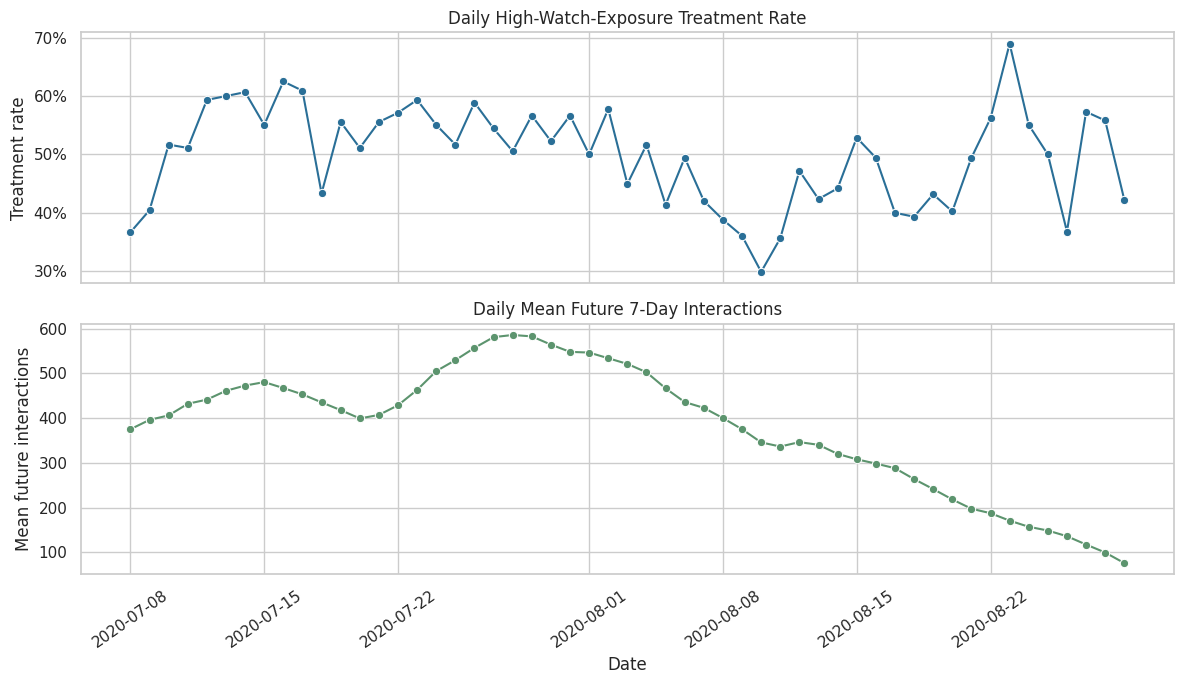

In [8]:
daily_summary = (
    panel.groupby("event_date")
    .agg(
        treatment_rate=(PRIMARY_TREATMENT, "mean"),
        mean_outcome=(PRIMARY_OUTCOME, "mean"),
        rows=(PRIMARY_TREATMENT, "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
sns.lineplot(data=daily_summary, x="event_date", y="treatment_rate", marker="o", ax=axes[0], color="#2A6F97")
axes[0].set_title("Daily High-Watch-Exposure Treatment Rate")
axes[0].set_ylabel("Treatment rate")
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

sns.lineplot(data=daily_summary, x="event_date", y="mean_outcome", marker="o", ax=axes[1], color="#5C946E")
axes[1].set_title("Daily Mean Future 7-Day Interactions")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Mean future interactions")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


The time-series view shows whether treatment and future engagement drift across the sample window. Any visible calendar movement supports keeping time controls in the treatment assignment model.


#### Treatment Rate by Prior User State

This cell bins important prior-history variables into quartiles and computes the treatment rate in each bin. If treatment rate changes across prior-activity bins, then prior state is part of the treatment assignment process and should be adjusted for.


In [9]:
# Treatment rate by prior user state.
def make_quantile_bucket(series, label_prefix):
    """
    Convert a numeric user-history variable into labeled quantile buckets.
    
    Idea
    ----
    The buckets support segment plots and balance diagnostics for lagged engagement variables in the sequential KuaiRec panel.
    
    Parameters
    ----------
    series : object
        Input pandas Series.
    label_prefix : object
        Prefix used when naming quantile buckets.
    
    Returns
    -------
    pandas.Series
        Categorical bucket labels aligned with the input series.
    """
    return pd.qcut(series, q=4, duplicates="drop").astype(str).rename(label_prefix)

history_bucket_df = panel[[PRIMARY_TREATMENT]].copy()
history_bucket_df["prior_3day_interactions_bucket"] = make_quantile_bucket(
    panel["prior_3day_interactions"], "prior_3day_interactions_bucket"
)
history_bucket_df["lag_1_watch_ratio_bucket"] = make_quantile_bucket(
    panel["lag_1_avg_watch_ratio"], "lag_1_watch_ratio_bucket"
)
history_bucket_df["prior_3day_watch_share_bucket"] = make_quantile_bucket(
    panel["prior_3day_high_watch_share"], "prior_3day_watch_share_bucket"
)

bucket_summaries = []
for bucket_col in ["prior_3day_interactions_bucket", "lag_1_watch_ratio_bucket", "prior_3day_watch_share_bucket"]:
    summary = (
        history_bucket_df.groupby(bucket_col, observed=True)[PRIMARY_TREATMENT]
        .agg(treatment_rate="mean", rows="size")
        .reset_index()
        .rename(columns={bucket_col: "bucket"})
    )
    summary.insert(0, "history_variable", bucket_col)
    bucket_summaries.append(summary)

history_treatment_rates = pd.concat(bucket_summaries, ignore_index=True)
display(history_treatment_rates)


,history_variable,bucket,treatment_rate,rows
0,prior_3day_interactions_bucket,"(-0.001, 123.0]",0.4920,1183
1,prior_3day_interactions_bucket,"(123.0, 166.0]",0.5178,1182
2,prior_3day_interactions_bucket,"(166.0, 217.0]",0.5198,1164
3,prior_3day_interactions_bucket,"(217.0, 581.0]",0.4688,1169
4,lag_1_watch_ratio_bucket,"(-0.001, 0.738]",0.2153,1175
5,lag_1_watch_ratio_bucket,"(0.738, 0.85]",0.4438,1174
6,lag_1_watch_ratio_bucket,"(0.85, 1.011]",0.6388,1174
7,lag_1_watch_ratio_bucket,"(1.011, 6.491]",0.7004,1175
8,prior_3day_watch_share_bucket,"(-0.001, 1.127]",0.1677,1175
9,prior_3day_watch_share_bucket,"(1.127, 1.414]",0.3424,1174


The bucket table checks whether treatment is more common for users with different recent activity or watch behavior. This is the empirical version of the confounding story from the previous map.


#### Plot Treatment Rate by Prior State

The table above is useful, but a faceted plot makes the pattern easier to scan. The goal is not to prove causality. The goal is to see whether pre-treatment history predicts treatment assignment strongly enough to justify propensity modeling.


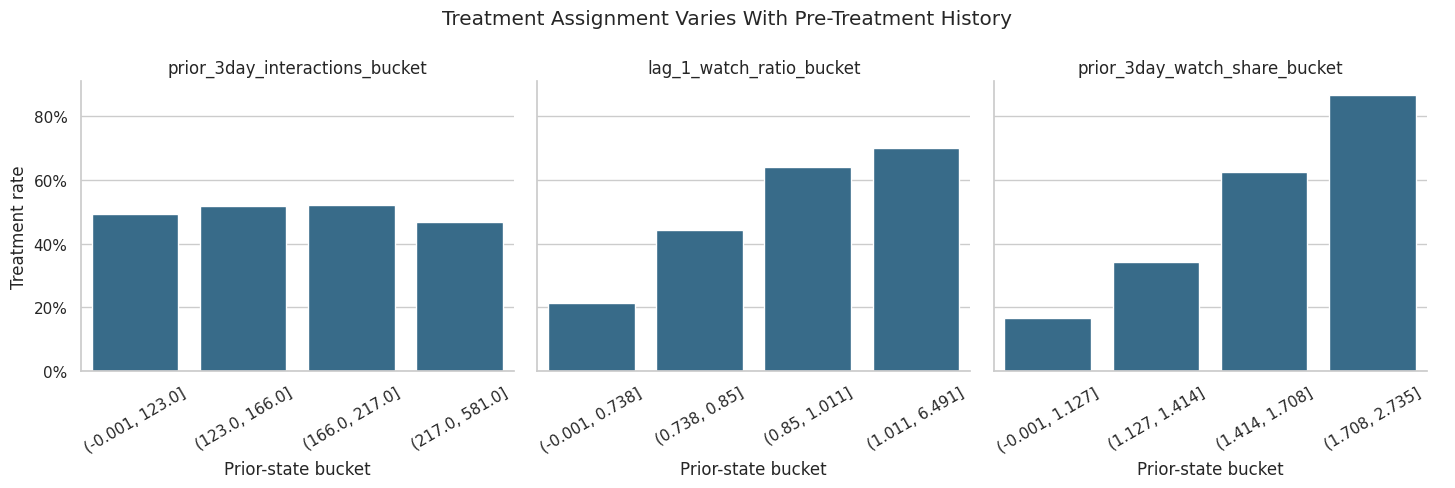

In [10]:
g = sns.catplot(
    data=history_treatment_rates,
    x="bucket",
    y="treatment_rate",
    col="history_variable",
    kind="bar",
    sharex=False,
    sharey=True,
    height=4,
    aspect=1.2,
    color="#2A6F97",
)
g.set_axis_labels("Prior-state bucket", "Treatment rate")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
g.fig.suptitle("Treatment Assignment Varies With Pre-Treatment History", y=1.08)
plt.show()


The plot helps reveal which prior-state variables are most associated with high-watch exposure. Stronger gradients indicate variables that the propensity model should capture to improve treated-control comparability.


### Unweighted Covariate Balance

Before modeling propensities, we measure treated-control imbalance using standardized mean differences. A standardized mean difference compares means in standard deviation units. Values farther from zero indicate stronger pre-treatment imbalance.


In [11]:
# Unweighted covariate balance.
def weighted_mean(values, weights):
    """
    Compute a weighted mean for causal diagnostics.
    
    Idea
    ----
    Use this helper when treated-control averages, covariate summaries, or estimator components need to respect inverse-propensity or stabilized weights.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted average after aligning values and weights and ignoring missing pairs.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(weights * values) / np.sum(weights)


def weighted_var(values, weights):
    """
    Compute a weighted variance for balance and uncertainty diagnostics.
    
    Idea
    ----
    The calculation supports weighted standardized mean differences by measuring spread under the same weighting scheme used for adjustment.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted variance of the non-missing values.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mean = weighted_mean(values, weights)
    return np.sum(weights * (values - mean) ** 2) / np.sum(weights)


def standardized_mean_difference(data, covariate, treatment_col=PRIMARY_TREATMENT, weight_col=None):
    """
    Compute a standardized mean difference for one covariate.
    
    Idea
    ----
    The helper compares treated and control covariate means, optionally under weights, to diagnose observed imbalance in the causal design.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    covariate : object
        Name of the covariate to summarize.
    treatment_col : object
        Column indicating treatment or exposure status.
    weight_col : object
        Column containing observation weights.
    
    Returns
    -------
    float
        Standardized mean difference for the requested column.
    """
    treated = data[treatment_col].eq(1)
    control = data[treatment_col].eq(0)

    if weight_col is None:
        treated_mean = data.loc[treated, covariate].mean()
        control_mean = data.loc[control, covariate].mean()
        treated_var = data.loc[treated, covariate].var(ddof=1)
        control_var = data.loc[control, covariate].var(ddof=1)
    else:
        treated_mean = weighted_mean(data.loc[treated, covariate], data.loc[treated, weight_col])
        control_mean = weighted_mean(data.loc[control, covariate], data.loc[control, weight_col])
        treated_var = weighted_var(data.loc[treated, covariate], data.loc[treated, weight_col])
        control_var = weighted_var(data.loc[control, covariate], data.loc[control, weight_col])

    pooled_sd = np.sqrt((treated_var + control_var) / 2)
    smd = (treated_mean - control_mean) / pooled_sd if pooled_sd > 0 else np.nan
    return treated_mean, control_mean, smd

balance_rows = []
for covariate in numeric_covariates:
    treated_mean, control_mean, smd = standardized_mean_difference(panel, covariate)
    balance_rows.append(
        {
            "covariate": covariate,
            "treated_mean": treated_mean,
            "control_mean": control_mean,
            "smd_unweighted": smd,
            "abs_smd_unweighted": abs(smd),
        }
    )

unweighted_balance = pd.DataFrame(balance_rows).sort_values("abs_smd_unweighted", ascending=False)
display(unweighted_balance)


,covariate,treated_mean,control_mean,smd_unweighted,abs_smd_unweighted
9,prior_3day_high_watch_share,1.6434,1.2077,1.2197,1.2197
4,lag_1_high_watch_share,0.5545,0.3979,1.0634,1.0634
8,prior_3day_avg_watch_ratio,3.0092,2.5157,0.5652,0.5652
3,lag_1_avg_watch_ratio,1.0098,0.8337,0.4654,0.4654
7,prior_3day_total_play_duration_sec,"1,605.1460","1,403.9936",0.2859,0.2859
2,lag_1_total_play_duration_sec,538.3737,466.2783,0.2329,0.2329
10,calendar_day_index,28.1542,29.5593,-0.0919,0.0919
11,panel_day_index,28.1542,29.5593,-0.0919,0.0919
6,prior_3day_interactions,171.3997,174.8337,-0.0487,0.0487
0,lag_1_active_day,0.9872,0.9830,0.0349,0.0349


The unweighted balance table shows which histories differ most between treated and control rows. Those imbalances are the main observed confounders that the propensity model and weights need to address.


#### Visualize Unweighted Balance

This plot ranks pre-treatment covariates by absolute imbalance. The reference lines at 0.1 and -0.1 are common practical guidelines for standardized mean differences.


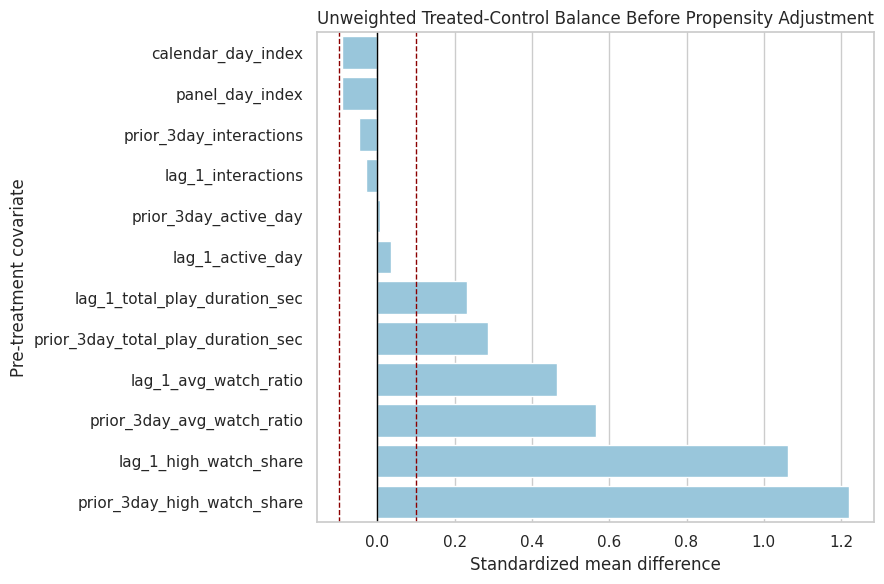

In [12]:
plot_balance = unweighted_balance.sort_values("smd_unweighted")

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=plot_balance, x="smd_unweighted", y="covariate", ax=ax, color="#8ECAE6")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.1, color="darkred", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="darkred", linestyle="--", linewidth=1)
ax.set_title("Unweighted Treated-Control Balance Before Propensity Adjustment")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("Pre-treatment covariate")
plt.tight_layout()
plt.show()


The balance plot makes the adjustment target visible. The next step is to estimate treatment probabilities from these histories so we can reweight the data toward better balance.


#### Define Propensity Model Pipelines

The primary propensity model is logistic regression because it is transparent and usually stable for weights. The comparison model is LightGBM because it can capture nonlinear treatment assignment and interactions. Both models use the same pre-treatment feature set.


In [13]:
# Define propensity model pipelines.
def make_logistic_propensity_pipeline(numeric_cols, categorical_cols):
    """
    Build a logistic propensity model for the KuaiRec treatment panel.
    
    Idea
    ----
    The model estimates treatment probability from lagged user history and calendar features, giving a transparent baseline for time-varying confounding diagnostics.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline that preprocesses covariates and predicts treatment propensity.
    """
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_cols),
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=1_000,
                    solver="lbfgs",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_lgbm_propensity_pipeline(numeric_cols, categorical_cols):
    """
    Build a LightGBM propensity model for flexible treatment assignment.
    
    Idea
    ----
    The model captures nonlinear relationships between lagged user history and treatment exposure in the KuaiRec sequential panel.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline that preprocesses covariates and predicts treatment propensity with LightGBM.
    """
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", "passthrough", numeric_cols),
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LGBMClassifier(
                    n_estimators=150,
                    learning_rate=0.04,
                    num_leaves=15,
                    min_child_samples=50,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    verbose=-1,
                ),
            ),
        ]
    )

propensity_models = {
    "logistic": make_logistic_propensity_pipeline(numeric_covariates, categorical_covariates),
    "lightgbm": make_lgbm_propensity_pipeline(numeric_covariates, categorical_covariates),
}

print("Defined propensity models:")
for model_name in propensity_models:
    print(f"- {model_name}")


Defined propensity models:
- logistic
- lightgbm


The two pipelines create a transparent baseline and a flexible comparison using the same legal covariates. Comparing them helps distinguish a real overlap problem from a modeling artifact.


### Cross-Fit Propensity Scores

Cross-fitting predicts treatment probabilities out of fold. This means each row's propensity score is produced by a model that did not train on that row. Cross-fitting is useful because it reduces overfitting in nuisance predictions, which is especially important when those predictions become inverse probability weights.


In [14]:
# Cross-fit propensity scores.
def cross_fitted_propensity(model, X, y, model_name, n_splits=5):
    """
    Generate cross-fitted propensity scores.
    
    Idea
    ----
    Cross-fitting keeps each row's treatment probability out of the model that was trained on that row, reducing overfitting in downstream weighting diagnostics.
    
    Parameters
    ----------
    model : object
        Fitted or unfitted model used in the helper.
    X : object
        Feature matrix.
    y : object
        Target vector.
    model_name : object
        Label identifying the model family or specification.
    n_splits : object
        Number of train/test splits or cross-fitting folds.
    
    Returns
    -------
    tuple[numpy.ndarray, pandas.DataFrame]
        Out-of-fold propensity predictions and fold-level model performance diagnostics.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    out_of_fold_prob = np.zeros(len(y), dtype=float)
    metric_rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        fold_model = clone(model)
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        fold_model.fit(X_train, y_train)
        fold_prob = fold_model.predict_proba(X_test)[:, 1]
        out_of_fold_prob[test_idx] = fold_prob

        metric_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "rows": len(test_idx),
                "treatment_rate": y_test.mean(),
                "roc_auc": roc_auc_score(y_test, fold_prob),
                "average_precision": average_precision_score(y_test, fold_prob),
                "brier_score": brier_score_loss(y_test, fold_prob),
                "log_loss": log_loss(y_test, fold_prob, labels=[0, 1]),
            }
        )

    full_model = clone(model).fit(X, y)
    return out_of_fold_prob, pd.DataFrame(metric_rows), full_model

X = panel[propensity_features].copy()
y = panel[PRIMARY_TREATMENT].astype(int)

propensity_outputs = {}
metric_frames = []
full_propensity_models = {}

for model_name, model in propensity_models.items():
    propensity, metrics, fitted_model = cross_fitted_propensity(model, X, y, model_name=model_name)
    propensity_outputs[model_name] = propensity
    metric_frames.append(metrics)
    full_propensity_models[model_name] = fitted_model
    panel[f"propensity_{model_name}"] = propensity

propensity_fold_metrics = pd.concat(metric_frames, ignore_index=True)
propensity_model_metrics = (
    propensity_fold_metrics.groupby("model")
    .agg(
        rows=("rows", "sum"),
        mean_treatment_rate=("treatment_rate", "mean"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        brier_score_mean=("brier_score", "mean"),
        log_loss_mean=("log_loss", "mean"),
    )
    .reset_index()
)

display(propensity_fold_metrics)
display(propensity_model_metrics)


,model,fold,rows,treatment_rate,roc_auc,average_precision,brier_score,log_loss
0,logistic,1,940,0.5000,0.8279,0.8183,0.1698,0.5132
1,logistic,2,940,0.5000,0.8174,0.8021,0.1741,0.5298
2,logistic,3,940,0.4989,0.8264,0.8222,0.1702,0.5110
3,logistic,4,939,0.4995,0.8436,0.8458,0.1617,0.4885
4,logistic,5,939,0.4995,0.8296,0.8285,0.1683,0.5092
5,lightgbm,1,940,0.5000,0.8285,0.8181,0.1702,0.5113
6,lightgbm,2,940,0.5000,0.8134,0.8055,0.1761,0.5336
7,lightgbm,3,940,0.4989,0.8286,0.8228,0.1692,0.5078
8,lightgbm,4,939,0.4995,0.8380,0.8371,0.1646,0.4964
9,lightgbm,5,939,0.4995,0.8315,0.8345,0.1674,0.5067


,model,rows,mean_treatment_rate,roc_auc_mean,roc_auc_std,average_precision_mean,brier_score_mean,log_loss_mean
0,lightgbm,4698,0.4996,0.8280,0.0090,0.8236,0.1695,0.5112
1,logistic,4698,0.4996,0.8290,0.0094,0.8234,0.1688,0.5103


The cross-fitted metrics show how predictable treatment is from observed pre-treatment history. Predictability is expected here. It confirms that high-watch exposure is selected by user state.


### Propensity Distributions

The next table summarizes each model's estimated treatment probabilities. Propensities near 0 or 1 are dangerous because they produce large weights. A good weighting setup needs enough overlap between treated and control rows.


In [15]:
propensity_summary_rows = []
for model_name in propensity_models:
    col = f"propensity_{model_name}"
    values = panel[col]
    propensity_summary_rows.append(
        {
            "model": model_name,
            "mean": values.mean(),
            "std": values.std(),
            "min": values.min(),
            "p01": values.quantile(0.01),
            "p05": values.quantile(0.05),
            "median": values.median(),
            "p95": values.quantile(0.95),
            "p99": values.quantile(0.99),
            "max": values.max(),
            "share_below_0_05": (values < 0.05).mean(),
            "share_above_0_95": (values > 0.95).mean(),
        }
    )

propensity_summary = pd.DataFrame(propensity_summary_rows)
display(propensity_summary)


,model,mean,std,min,p01,p05,median,p95,p99,max,share_below_0_05,share_above_0_95
0,logistic,0.4995,0.2863,0.0028,0.0303,0.0776,0.4887,0.9457,0.9830,0.9947,0.0217,0.0447
1,lightgbm,0.4985,0.2930,0.0218,0.0382,0.0686,0.5017,0.9396,0.9689,0.9788,0.0243,0.0349


The propensity summary is the first positivity check. If a model produces many probabilities close to 0 or 1, weights from that model would be unstable and the causal estimate would depend on a thin region of overlap.


#### Plot Propensity Overlap

This plot compares propensity distributions for treated and control rows. Strong overlap means treated and control user-days have comparable predicted treatment probabilities. Weak overlap means the observed data contains few comparable rows for some histories.


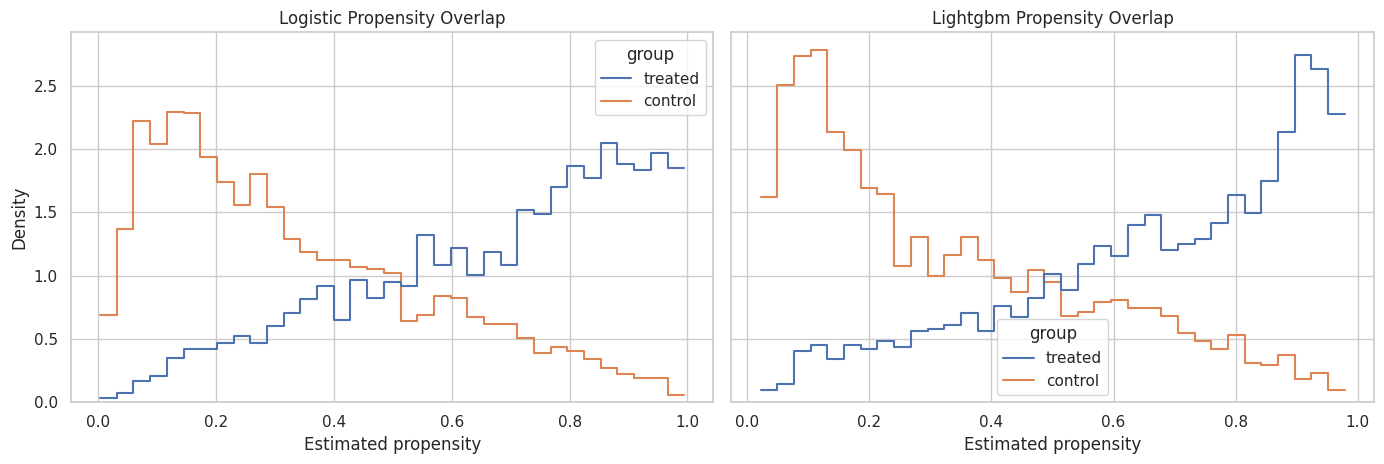

In [16]:
# Plot propensity overlap.
propensity_long = panel[[PRIMARY_TREATMENT, "propensity_logistic", "propensity_lightgbm"]].melt(
    id_vars=PRIMARY_TREATMENT,
    var_name="model",
    value_name="propensity",
)
propensity_long["model"] = propensity_long["model"].str.replace("propensity_", "", regex=False)
propensity_long["group"] = np.where(propensity_long[PRIMARY_TREATMENT].eq(1), "treated", "control")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, model_name in zip(axes, ["logistic", "lightgbm"]):
    sns.histplot(
        data=propensity_long.query("model == @model_name"),
        x="propensity",
        hue="group",
        bins=35,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(f"{model_name.title()} Propensity Overlap")
    ax.set_xlabel("Estimated propensity")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


The overlap plot shows whether treated and control histories occupy similar propensity ranges. The primary weights should come from a model that captures selection while preserving usable overlap.


### Propensity Calibration by Decile

A propensity model should rank rows by treatment likelihood and place them on a reasonable probability scale. The next cell bins predictions into deciles and compares predicted treatment probability with observed treatment frequency.


In [17]:
# Propensity calibration by decile.
def calibration_table(data, propensity_col, treatment_col=PRIMARY_TREATMENT, n_bins=10):
    """
    Create a calibration table for predicted probabilities.
    
    Idea
    ----
    The table compares average predictions with observed outcomes across bins so nuisance-model reliability can be checked before causal estimates are trusted.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    propensity_col : object
        Project-specific input named `propensity_col` used by this helper.
    treatment_col : object
        Column indicating treatment or exposure status.
    n_bins : object
        Number of bins used for calibration summaries.
    
    Returns
    -------
    pandas.DataFrame
        Binned calibration summary with predicted and observed rates.
    """
    table = data[[propensity_col, treatment_col]].copy()
    table["propensity_bin"] = pd.qcut(table[propensity_col], q=n_bins, duplicates="drop")
    return (
        table.groupby("propensity_bin", observed=True)
        .agg(
            rows=(treatment_col, "size"),
            mean_predicted_propensity=(propensity_col, "mean"),
            observed_treatment_rate=(treatment_col, "mean"),
        )
        .reset_index()
    )

calibration_frames = []
for model_name in propensity_models:
    frame = calibration_table(panel, f"propensity_{model_name}")
    frame.insert(0, "model", model_name)
    calibration_frames.append(frame)

propensity_calibration = pd.concat(calibration_frames, ignore_index=True)
display(propensity_calibration)


,model,propensity_bin,rows,mean_predicted_propensity,observed_treatment_rate
0,logistic,"(0.00178, 0.119]",470,0.0734,0.0723
1,logistic,"(0.119, 0.196]",470,0.1562,0.1532
2,logistic,"(0.196, 0.287]",470,0.2418,0.2213
3,logistic,"(0.287, 0.386]",469,0.3359,0.3582
4,logistic,"(0.386, 0.489]",470,0.4377,0.4383
5,logistic,"(0.489, 0.597]",470,0.5439,0.5723
6,logistic,"(0.597, 0.707]",469,0.6502,0.6183
7,logistic,"(0.707, 0.809]",470,0.7584,0.7851
8,logistic,"(0.809, 0.898]",470,0.8520,0.8574
9,logistic,"(0.898, 0.995]",470,0.9451,0.9191


The calibration table checks whether predicted probabilities line up with observed treatment rates. Reasonable calibration is important because inverse probability weights use probability magnitudes. The implication is practical. Poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Plot Propensity Calibration

The dashed diagonal represents perfect calibration. Points above the line mean the observed treatment rate is higher than predicted. Points below the line mean the model overpredicts treatment frequency.


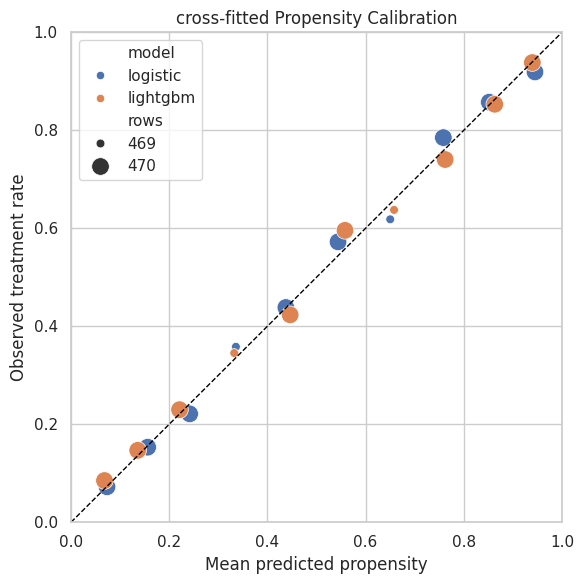

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=propensity_calibration,
    x="mean_predicted_propensity",
    y="observed_treatment_rate",
    hue="model",
    size="rows",
    sizes=(40, 160),
    ax=ax,
)
ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
ax.set_title("cross-fitted Propensity Calibration")
ax.set_xlabel("Mean predicted propensity")
ax.set_ylabel("Observed treatment rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


The calibration plot helps decide whether a model is safe to use for weighting. A model with good discrimination but poor probability calibration can still create misleading weights.


#### Define Stabilized Inverse Probability Weights

For a point-treatment marginal structural model, the unstabilized inverse probability weight is `1 / e(X)` for treated rows and `1 / (1 - e(X))` for control rows. Stabilized weights multiply the numerator by the marginal treatment probability. Stabilization keeps the target population closer to the observed sample and reduces variance.

This notebook uses logistic-regression propensities as the primary weights because they are transparent and typically less extreme. LightGBM weights are kept as a diagnostic comparison.


In [19]:
# Define stabilized inverse probability weights.
def add_stabilized_weights(data, propensity_col, prefix, treatment_col=PRIMARY_TREATMENT, eps=1e-6):
    """
    Add stabilized inverse-propensity weights to the panel.
    
    Idea
    ----
    The function combines marginal treatment probability with individual propensity scores to create MSM weights and clipped diagnostics.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    propensity_col : object
        Project-specific input named `propensity_col` used by this helper.
    prefix : object
        Prefix used when naming new weight columns.
    treatment_col : object
        Column indicating treatment or exposure status.
    eps : object
        Small positive value used to avoid division by zero.
    
    Returns
    -------
    pandas.DataFrame
        Copy of the input data with stabilized weight columns added.
    """
    result = data.copy()
    treatment = result[treatment_col].astype(int)
    propensity = result[propensity_col].clip(eps, 1 - eps)
    marginal_treatment_rate = treatment.mean()

    result[f"ipw_{prefix}"] = np.where(
        treatment.eq(1),
        1 / propensity,
        1 / (1 - propensity),
    )
    result[f"sw_{prefix}"] = np.where(
        treatment.eq(1),
        marginal_treatment_rate / propensity,
        (1 - marginal_treatment_rate) / (1 - propensity),
    )
    return result

weighted_panel = panel.copy()
weighted_panel = add_stabilized_weights(weighted_panel, "propensity_logistic", "logistic")
weighted_panel = add_stabilized_weights(weighted_panel, "propensity_lightgbm", "lightgbm")

PRIMARY_PROPENSITY_COL = "propensity_logistic"
PRIMARY_WEIGHT_COL = "sw_logistic"

weight_preview_cols = [
    PRIMARY_TREATMENT,
    "propensity_logistic",
    "sw_logistic",
    "propensity_lightgbm",
    "sw_lightgbm",
]

display(weighted_panel[weight_preview_cols].head(10))


,treatment,propensity_logistic,sw_logistic,propensity_lightgbm,sw_lightgbm
0,1,0.5471,0.9131,0.5266,0.9487
1,0,0.6333,1.3647,0.5373,1.0816
2,1,0.4140,1.2067,0.5234,0.9544
3,1,0.5654,0.8836,0.6503,0.7682
4,0,0.5986,1.2466,0.7418,1.9378
5,1,0.5141,0.9718,0.7059,0.7077
6,1,0.5511,0.9065,0.5565,0.8978
7,1,0.5693,0.8775,0.7866,0.6351
8,1,0.8006,0.6240,0.8249,0.6056
9,1,0.7779,0.6422,0.8345,0.5987


The panel now contains stabilized weights for both propensity models. The logistic stabilized weight is selected as the primary weight for the next notebook, while LightGBM remains available for sensitivity checks.


### Weight Distribution Diagnostics

Weights should be centered near 1 and should not have extreme tails. This cell summarizes the unstabilized and stabilized weights from both propensity models. Extreme weights indicate limited overlap or overly confident propensity predictions.


In [20]:
# Weight distribution diagnostics.
def effective_sample_size(weights):
    """
    Compute the effective sample size implied by importance weights.
    
    Idea
    ----
    Large or unstable weights can make an estimator behave as if it had far fewer observations; this diagnostic turns weight concentration into a readable sample-size number.
    
    Parameters
    ----------
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Effective sample size computed as squared total weight divided by total squared weight.
    """
    weights = np.asarray(weights, dtype=float)
    return (weights.sum() ** 2) / np.sum(weights ** 2)

weight_columns = ["ipw_logistic", "sw_logistic", "ipw_lightgbm", "sw_lightgbm"]
weight_summary_rows = []
for weight_col in weight_columns:
    values = weighted_panel[weight_col]
    weight_summary_rows.append(
        {
            "weight": weight_col,
            "mean": values.mean(),
            "std": values.std(),
            "min": values.min(),
            "p50": values.quantile(0.50),
            "p90": values.quantile(0.90),
            "p95": values.quantile(0.95),
            "p99": values.quantile(0.99),
            "max": values.max(),
            "effective_sample_size": effective_sample_size(values),
            "ess_share_of_rows": effective_sample_size(values) / len(values),
        }
    )

weight_diagnostics = pd.DataFrame(weight_summary_rows)
display(weight_diagnostics)


,weight,mean,std,min,p50,p90,p95,p99,max,effective_sample_size,ess_share_of_rows
0,ipw_logistic,2.0767,3.4301,1.0028,1.3945,3.2625,4.7814,11.4275,119.9903,"1,260.3721",0.2683
1,sw_logistic,1.0384,1.7153,0.5018,0.6973,1.6307,2.3921,5.7092,59.9441,"1,260.0838",0.2682
2,ipw_lightgbm,2.0541,2.2425,1.0216,1.3874,3.3732,5.1568,11.7539,45.0967,"2,143.6149",0.4563
3,sw_lightgbm,1.0270,1.1213,0.5104,0.6935,1.6872,2.5799,5.8723,22.5676,"2,143.4028",0.4562


The weight diagnostics show how much precision is lost after weighting. A large effective sample size and modest tails suggest the weighted analysis is numerically feasible. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


#### Plot Stabilized Weight Distributions

The weight plot visualizes the tails that are easy to miss in a summary table. Stabilized weights should ideally be compact. Long right tails warn that some rows carry much more influence than others.


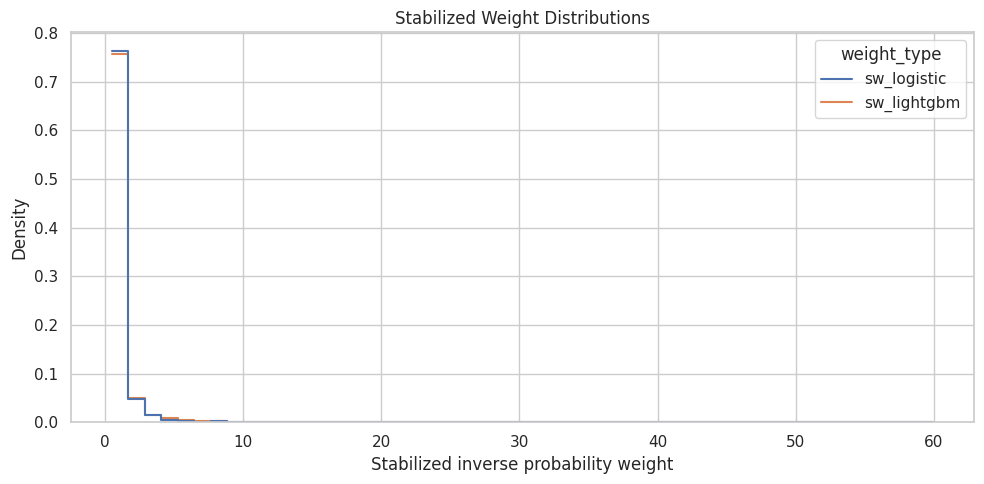

In [21]:
weight_plot_df = weighted_panel[["sw_logistic", "sw_lightgbm"]].melt(
    var_name="weight_type",
    value_name="weight",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=weight_plot_df,
    x="weight",
    hue="weight_type",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=ax,
)
ax.set_title("Stabilized Weight Distributions")
ax.set_xlabel("Stabilized inverse probability weight")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


The plot checks whether either model creates noticeably heavier weight tails. If the flexible model creates much wider weights, the transparent logistic model is a safer primary choice for the marginal structural model.


#### Weight Clipping Sensitivity

Even with reasonable overlap, it is common to inspect clipped weights. Clipping caps the largest weights to reduce variance, at the cost of changing the target estimand slightly. This cell creates clipped versions of the primary stabilized weight and records effective sample size.


In [22]:
clip_values = [None, 2, 5, 10]
clipping_rows = []

for clip_value in clip_values:
    if clip_value is None:
        clipped_col = "sw_logistic"
        clipped_values = weighted_panel[PRIMARY_WEIGHT_COL]
        label = "unclipped"
    else:
        clipped_col = f"sw_logistic_clip_{clip_value}"
        clipped_values = weighted_panel[PRIMARY_WEIGHT_COL].clip(upper=clip_value)
        weighted_panel[clipped_col] = clipped_values
        label = f"clip_at_{clip_value}"

    clipping_rows.append(
        {
            "weight_version": label,
            "weight_column": clipped_col,
            "mean_weight": clipped_values.mean(),
            "max_weight": clipped_values.max(),
            "effective_sample_size": effective_sample_size(clipped_values),
            "ess_share_of_rows": effective_sample_size(clipped_values) / len(clipped_values),
        }
    )

clipping_diagnostics = pd.DataFrame(clipping_rows)
display(clipping_diagnostics)


,weight_version,weight_column,mean_weight,max_weight,effective_sample_size,ess_share_of_rows
0,unclipped,sw_logistic,1.0384,59.9441,"1,260.0838",0.2682
1,clip_at_2,sw_logistic_clip_2,0.8798,2.0000,"3,797.3068",0.8083
2,clip_at_5,sw_logistic_clip_5,0.9684,5.0000,"2,932.2499",0.6241
3,clip_at_10,sw_logistic_clip_10,1.0014,10.0000,"2,400.8979",0.5110


The clipping table shows whether capping extreme weights materially changes the effective sample size. If clipping barely changes ESS, the primary weights are already stable; if it changes ESS a lot, later estimates should include clipping sensitivity.


#### Choose the Primary Analysis Weight

The next notebook needs one default weight column. We use the logistic stabilized weight with a conservative cap at 10. If the raw weights are already below that cap, this column will match the raw logistic stabilized weights. Keeping an explicit primary column makes downstream notebooks simpler and more auditable.


In [23]:
PRIMARY_ANALYSIS_WEIGHT_COL = "analysis_weight"
WEIGHT_CLIP_VALUE = 10

weighted_panel[PRIMARY_ANALYSIS_WEIGHT_COL] = weighted_panel[PRIMARY_WEIGHT_COL].clip(upper=WEIGHT_CLIP_VALUE)

primary_weight_summary = pd.Series(
    {
        "source_propensity": PRIMARY_PROPENSITY_COL,
        "source_weight": PRIMARY_WEIGHT_COL,
        "analysis_weight": PRIMARY_ANALYSIS_WEIGHT_COL,
        "clip_value": WEIGHT_CLIP_VALUE,
        "mean": weighted_panel[PRIMARY_ANALYSIS_WEIGHT_COL].mean(),
        "max": weighted_panel[PRIMARY_ANALYSIS_WEIGHT_COL].max(),
        "effective_sample_size": effective_sample_size(weighted_panel[PRIMARY_ANALYSIS_WEIGHT_COL]),
        "ess_share_of_rows": effective_sample_size(weighted_panel[PRIMARY_ANALYSIS_WEIGHT_COL]) / len(weighted_panel),
    }
).rename("value")

display(primary_weight_summary)


source_propensity        propensity_logistic
source_weight                    sw_logistic
analysis_weight              analysis_weight
clip_value                                10
mean                                  1.0014
max                                  10.0000
effective_sample_size             2,400.8979
ess_share_of_rows                     0.5110
Name: value, dtype: object

The selected `analysis_weight` column is the practical handoff to the marginal structural model. It makes the next notebook cleaner because the default weighting choice is documented here.


### Weighted Covariate Balance

The purpose of inverse probability weighting is to make treated and control rows more similar on observed pre-treatment history. The next cell recomputes standardized mean differences using the selected analysis weight and compares them with the original unweighted imbalance.


In [24]:
weighted_balance_rows = []
for covariate in numeric_covariates:
    treated_mean_w, control_mean_w, smd_w = standardized_mean_difference(
        weighted_panel,
        covariate,
        weight_col=PRIMARY_ANALYSIS_WEIGHT_COL,
    )
    weighted_balance_rows.append(
        {
            "covariate": covariate,
            "treated_mean_weighted": treated_mean_w,
            "control_mean_weighted": control_mean_w,
            "smd_weighted": smd_w,
            "abs_smd_weighted": abs(smd_w),
        }
    )

weighted_balance = pd.DataFrame(weighted_balance_rows)
balance_diagnostics = unweighted_balance.merge(weighted_balance, on="covariate", how="left")
balance_diagnostics["abs_smd_reduction"] = (
    balance_diagnostics["abs_smd_unweighted"] - balance_diagnostics["abs_smd_weighted"]
)

balance_diagnostics = balance_diagnostics.sort_values("abs_smd_unweighted", ascending=False)
display(balance_diagnostics)


,covariate,treated_mean,control_mean,smd_unweighted,abs_smd_unweighted,treated_mean_weighted,control_mean_weighted,smd_weighted,abs_smd_weighted,abs_smd_reduction
0,prior_3day_high_watch_share,1.6434,1.2077,1.2197,1.2197,1.4361,1.4354,0.0018,0.0018,1.2179
1,lag_1_high_watch_share,0.5545,0.3979,1.0634,1.0634,0.4795,0.4752,0.0266,0.0266,1.0369
2,prior_3day_avg_watch_ratio,3.0092,2.5157,0.5652,0.5652,2.7649,2.7524,0.0142,0.0142,0.5510
3,lag_1_avg_watch_ratio,1.0098,0.8337,0.4654,0.4654,0.9253,0.9159,0.0240,0.0240,0.4415
4,prior_3day_total_play_duration_sec,"1,605.1460","1,403.9936",0.2859,0.2859,"1,491.4685","1,471.8861",0.0282,0.0282,0.2577
5,lag_1_total_play_duration_sec,538.3737,466.2783,0.2329,0.2329,497.9161,495.5466,0.0075,0.0075,0.2254
6,calendar_day_index,28.1542,29.5593,-0.0919,0.0919,29.4525,29.6002,-0.0095,0.0095,0.0824
7,panel_day_index,28.1542,29.5593,-0.0919,0.0919,29.4525,29.6002,-0.0095,0.0095,0.0824
8,prior_3day_interactions,171.3997,174.8337,-0.0487,0.0487,171.6769,170.2261,0.0204,0.0204,0.0283
9,lag_1_active_day,0.9872,0.9830,0.0349,0.0349,0.9861,0.9863,-0.0010,0.0010,0.0339


The weighted balance table checks whether the chosen weights reduce observed confounding. Improvement here is a key prerequisite before using the weights in a marginal structural model. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


#### Plot Balance Before and After Weighting

The plot compares absolute standardized mean differences before and after weighting. Good weighting should move most covariates closer to zero, ideally below the practical 0.1 threshold.


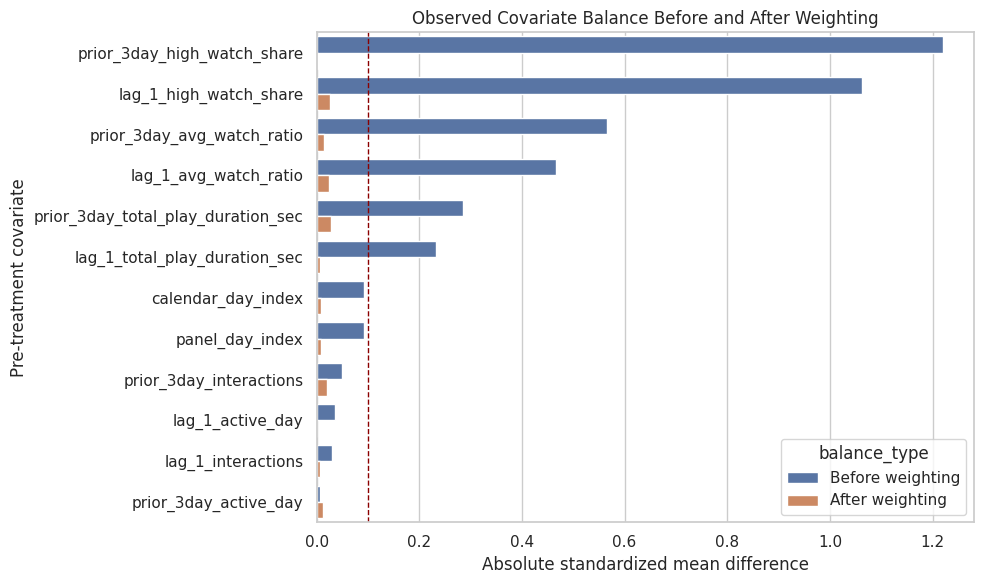

In [25]:
# Plot balance before and after weighting.
balance_plot_df = balance_diagnostics[["covariate", "abs_smd_unweighted", "abs_smd_weighted"]].melt(
    id_vars="covariate",
    var_name="balance_type",
    value_name="absolute_smd",
)
balance_plot_df["balance_type"] = balance_plot_df["balance_type"].map(
    {
        "abs_smd_unweighted": "Before weighting",
        "abs_smd_weighted": "After weighting",
    }
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=balance_plot_df,
    x="absolute_smd",
    y="covariate",
    hue="balance_type",
    ax=ax,
)
ax.axvline(0.1, color="darkred", linestyle="--", linewidth=1)
ax.set_title("Observed Covariate Balance Before and After Weighting")
ax.set_xlabel("Absolute standardized mean difference")
ax.set_ylabel("Pre-treatment covariate")
plt.tight_layout()
plt.show()


The balance plot is the main diagnostic for whether the propensity weights are doing useful adjustment work. Remaining large imbalances would need to be addressed before trusting the weighted effect estimate.


#### Weighted Outcome Preview

This cell computes a simple weighted treated-control outcome difference using the analysis weights. It previews how much the naive difference changes after reweighting observed histories before the final marginal structural model.


In [26]:
# Weighted outcome preview.
def group_weighted_mean(data, group_value, outcome_col=PRIMARY_OUTCOME, weight_col=PRIMARY_ANALYSIS_WEIGHT_COL):
    """
    Compute a group-specific weighted outcome mean.
    
    Idea
    ----
    This helper compares adjusted outcomes inside treatment groups, segments, or exposure groups while using the same weights as the causal estimator.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    group_value : object
        Project-specific input named `group_value` used by this helper.
    outcome_col : object
        Outcome column used in the estimator.
    weight_col : object
        Column containing observation weights.
    
    Returns
    -------
    float
        Weighted mean outcome for the selected group.
    """
    subset = data.loc[data[PRIMARY_TREATMENT].eq(group_value)]
    return weighted_mean(subset[outcome_col], subset[weight_col])

weighted_control_mean = group_weighted_mean(weighted_panel, 0)
weighted_treated_mean = group_weighted_mean(weighted_panel, 1)
weighted_difference = weighted_treated_mean - weighted_control_mean
weighted_lift = weighted_difference / weighted_control_mean

weighted_outcome_preview = pd.DataFrame(
    [
        {"estimate": "naive_difference", "value": naive_difference, "relative_lift": naive_lift},
        {"estimate": "weighted_difference_preview", "value": weighted_difference, "relative_lift": weighted_lift},
    ]
)

display(weighted_outcome_preview)


,estimate,value,relative_lift
0,naive_difference,7.0755,0.0187
1,weighted_difference_preview,-1.7389,-0.0046


The weighted preview shows whether adjustment changes the direction or size of the raw treated-control difference. The formal effect estimate still belongs in the next notebook, but this preview confirms that the weights have practical consequences.


#### Positivity and Weight Readiness Checklist

This checklist summarizes whether the weighted panel is ready for a marginal structural model. It does not prove causal identification, because unobserved confounding can still exist. It does check the observable requirements we can diagnose: overlap, stable weights, effective sample size, and improved covariate balance.


In [27]:
# Positivity and weight readiness checklist.
max_abs_smd_before = balance_diagnostics["abs_smd_unweighted"].max()
max_abs_smd_after = balance_diagnostics["abs_smd_weighted"].max()
mean_abs_smd_before = balance_diagnostics["abs_smd_unweighted"].mean()
mean_abs_smd_after = balance_diagnostics["abs_smd_weighted"].mean()
analysis_weight_ess = effective_sample_size(weighted_panel[PRIMARY_ANALYSIS_WEIGHT_COL])

readiness_checks = pd.DataFrame(
    [
        {
            "check": "no propensity below 0.05 or above 0.95 for most rows",
            "value": ((weighted_panel[PRIMARY_PROPENSITY_COL] < 0.05) | (weighted_panel[PRIMARY_PROPENSITY_COL] > 0.95)).mean(),
            "passes": ((weighted_panel[PRIMARY_PROPENSITY_COL] < 0.05) | (weighted_panel[PRIMARY_PROPENSITY_COL] > 0.95)).mean() < 0.05,
        },
        {
            "check": "analysis weight max below clipping cap",
            "value": weighted_panel[PRIMARY_ANALYSIS_WEIGHT_COL].max(),
            "passes": weighted_panel[PRIMARY_ANALYSIS_WEIGHT_COL].max() <= WEIGHT_CLIP_VALUE,
        },
        {
            "check": "effective sample size at least 70% of rows",
            "value": analysis_weight_ess / len(weighted_panel),
            "passes": analysis_weight_ess / len(weighted_panel) >= 0.70,
        },
        {
            "check": "mean absolute SMD improves after weighting",
            "value": mean_abs_smd_before - mean_abs_smd_after,
            "passes": mean_abs_smd_after < mean_abs_smd_before,
        },
        {
            "check": "maximum absolute SMD improves after weighting",
            "value": max_abs_smd_before - max_abs_smd_after,
            "passes": max_abs_smd_after < max_abs_smd_before,
        },
    ]
)

display(readiness_checks)


,check,value,passes
0,no propensity below 0.05 or above 0.95 for mos...,0.0664,False
1,analysis weight max below clipping cap,10.0000,True
2,effective sample size at least 70% of rows,0.5110,False
3,mean absolute SMD improves after weighting,0.3311,True
4,maximum absolute SMD improves after weighting,1.1915,True


The readiness checklist turns the diagnostics into a clear decision point. If these checks mostly pass, the weighted panel is suitable for Notebook 04; if not, the project would need stronger treatment models or additional covariates.


#### Save the Weighted Panel and Diagnostics

The next notebook should not refit the propensity models. It should load the weighted panel saved here and focus on estimating the long-term effect. This cell saves the weighted panel plus supporting diagnostics so the modeling choices remain auditable.


In [28]:
weighted_panel_path = PROCESSED_DIR / "kuairec_long_term_weighted_panel.parquet"
propensity_metrics_path = PROCESSED_DIR / "kuairec_long_term_propensity_model_metrics.csv"
weight_diagnostics_path = PROCESSED_DIR / "kuairec_long_term_weight_diagnostics.csv"
balance_diagnostics_path = PROCESSED_DIR / "kuairec_long_term_balance_diagnostics.csv"
readiness_checks_path = PROCESSED_DIR / "kuairec_long_term_weight_readiness_checks.csv"

weighted_panel.to_parquet(weighted_panel_path, index=False)
propensity_model_metrics.to_csv(propensity_metrics_path, index=False)
weight_diagnostics.to_csv(weight_diagnostics_path, index=False)
balance_diagnostics.to_csv(balance_diagnostics_path, index=False)
readiness_checks.to_csv(readiness_checks_path, index=False)

print("Saved Notebook 03 artifacts:")
print(f"- {weighted_panel_path}")
print(f"- {propensity_metrics_path}")
print(f"- {weight_diagnostics_path}")
print(f"- {balance_diagnostics_path}")
print(f"- {readiness_checks_path}")


Saved Notebook 03 artifacts:
- /home/apex/Documents/portfolio/data/processed/kuairec_long_term_weighted_panel.parquet
- /home/apex/Documents/portfolio/data/processed/kuairec_long_term_propensity_model_metrics.csv
- /home/apex/Documents/portfolio/data/processed/kuairec_long_term_weight_diagnostics.csv
- /home/apex/Documents/portfolio/data/processed/kuairec_long_term_balance_diagnostics.csv
- /home/apex/Documents/portfolio/data/processed/kuairec_long_term_weight_readiness_checks.csv


The weighted panel and diagnostics are now persisted. This creates a clean handoff: Notebook 04 can estimate a marginal structural model using `analysis_weight` without repeating treatment-assignment modeling.


## Takeaways and Next Step

This notebook showed that high-watch exposure is related to pre-treatment user history, which supports the claim that the problem involves time-varying confounding. It then estimated cross-fitted propensity scores, checked overlap and calibration, created stabilized inverse probability weights, and verified whether those weights improve observed covariate balance.

The next notebook should use `data/processed/kuairec_long_term_weighted_panel.parquet` to estimate the long-term causal effect with a marginal structural model. The default treatment column is `treatment`, the default outcome column is `outcome`, and the default weight column is `analysis_weight`.
